# REVISÃO GLOBAL (1º BIMESTRE)
**O Caso TechMarket: Do Caos à Inteligência Artificial**

**A Missão:** Você foi contratado como Cientista de Dados Sênior do e-commerce *TechMarket*. A empresa possui um banco de dados sujo e precisa que você passe por todo o ciclo de vida dos dados: desde adequação à LGPD, extração de relatórios descritivos, validação de um Teste A/B da nova interface, até a criação de um algoritmo preditivo.

---
### FASE 0: O Setup (Criação do Universo)

Base gerada com sucesso! Bem-vindo à TechMarket.
A moda da coluna 'Regiao' é: Sudeste


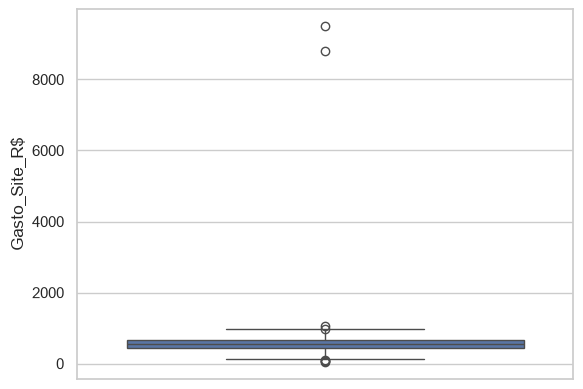

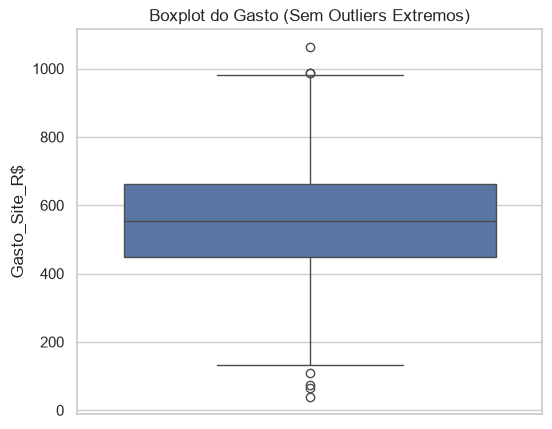

In [ ]:
# RODAR ESTA CÉLULA PARA INICIALIZAR O AMBIENTE (CÓDIGO FORNECIDO)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

# --- GERANDO A BASE SINTÉTICA DA TECHMARKET ---
np.random.seed(42)
n_clientes = 1000

idades = np.random.randint(18, 65, n_clientes)
emails = [f"cliente_{i}@email.com" for i in range(n_clientes)]
regioes = np.random.choice(['Sul', 'Sudeste', 'Nordeste'], n_clientes, p=[0.2, 0.5, 0.3])
versoes = np.random.choice(['A', 'B'], n_clientes)

tempo_A = np.random.normal(15, 5, 500) 
tempo_B = np.random.normal(17, 5, 500) 
tempo_tela = np.concatenate([tempo_A, tempo_B])
np.random.shuffle(tempo_tela)

gasto = (tempo_tela * 25) + 150 + np.random.normal(0, 100, n_clientes)

# Criando anomalias/outliers para atrapalhar as análises
gasto[10] = 9500
gasto[50] = 8800

df = pd.DataFrame({
    'Idade': idades,
    'Email': emails,
    'Regiao': regioes,
    'Versao_Site': versoes,
    'Tempo_Tela_Min': np.abs(tempo_tela),
    'Gasto_Site_R$': np.abs(gasto)
})

print("Base gerada com sucesso! Bem-vindo à TechMarket.")


moda = df['Regiao'].mode()[0]
print(f"A moda da coluna 'Regiao' é: {moda}")
df.head()

sns.boxplot(
    data=df,
    y='Gasto_Site_R$'
)

plt.show()




### FASE 1: O Alerta Jurídico (LGPD)
A base contém Informações Pessoalmente Identificáveis (PII). A equipe de Data Science não precisa expor a identidade dos usuários para prever faturamento.

In [7]:
# MISSÃO 1:
# 1. Exclua a coluna que expõe a identidade do cliente usando a função apropriada do Pandas.
# 2. Salve o resultado numa variável chamada 'df_seguro'.
# 3. Mostre as primeiras linhas da nova base para confirmar.

# SEU CÓDIGO AQUI:
df_seguro = df.drop('Email', axis=1, inplace=True)
df_seguro.head()


AttributeError: 'NoneType' object has no attribute 'head'

### FASE 2: O Raio-X Estatístico (Diagnosticando o Passado)
A diretoria de vendas precisa de um retrato rápido de quem é o cliente atual da TechMarket.

In [10]:
# MISSÃO 2:
# 1. Qual é a Região que mais acessa o site? Encontre e imprima a MODA.
moda = df['Regiao'].mode()[0]
print(f"A moda da coluna 'Regiao' é: {moda}")
# 2. Qual é a MÉDIA da coluna 'Gasto_Site_R$'?
media = df['Gasto_Site_R$'].median()
print(f"A media de gastos é : {media}")
# 3. Qual é a MEDIANA da coluna 'Gasto_Site_R$'?
mediana = df['Gasto_Site_R$'].mean()
print(f"A mediana de gastos é : {mediana}")
# 4. Comente (#) logo abaixo: Comparando a média e a mediana, a sua base parece ter Outliers? Por quê?

# SEU CÓDIGO E RESPOSTA AQUI:



A moda da coluna 'Regiao' é: Sudeste
A media de gastos é : 555.5866772080753
A mediana de gastos é : 569.8882303246002


### FASE 3: Tradução Visual
A diretoria não lê terminais de código. Precisamos provar os números com gráficos.

In [ ]:
# MISSÃO 3:
# Usando o Seaborn (sns):
# 1. Plote um gráfico de Barras (barplot) mostrando o Gasto (y) separado por Regiao (x).
sns.barplot(
    data=df,
    x='Regiao',
    y='Gasto_Site_R$'
)
plt.show()
# 2. Plote um Gráfico de Caixa (boxplot) do Gasto geral do site.
sns.boxplot(
    data=df,
    x='Regiao',
    y='Gasto_Site_R$'
)
df_filtrado = df[df['Gasto_Site_R$'] < 3000]

plt.figure(figsize=(6, 5))
sns.boxplot(data=df_filtrado, y='Gasto_Site_R$')
plt.title("Boxplot do Gasto (Sem Outliers Extremos)")

plt.show()
# 3. Comente (#): O boxplot ajudou a confirmar a sua desconfiança da Fase 2 sobre os Outliers? #sim tem dois pontos muito isolados no nordeste e sudeste acima de 8000 possivel erro de digitação

# SEU CÓDIGO E RESPOSTA AQUI:




### FASE 4: O Tribunal da Ciência (Teste A/B)
A equipe de UX lançou a Versão B do site (com botões laranjas) apostando que ela prenderia o cliente por mais tempo na tela do que a Versão A (Verde).

- **H0 (Nula):** O tempo de tela é igual. O acaso manda.
- **H1 (Alternativa):** O tempo de tela da versão B é matematicamente distinto.

In [ ]:
# MISSÃO 4:
# 1. Isole em uma variável (tempo_A) todo o 'Tempo_Tela_Min' apenas de quem acessou a 'Versao_Site' A.
# 2. Faça o mesmo para a Versão B (tempo_B).
# 3. Use o stats.ttest_ind do SciPy para comparar os dois grupos e extrair o p-valor.
# 4. Crie um IF/ELSE usando a regra de alfa (0.05). Se p < 0.05, imprima que a diferença é real e faça o deploy. Senão, chancele como ruído.

# SEU CÓDIGO AQUI:



### FASE 5: Correlação e o Motor de Previsão
Será que o Tempo de Tela puxa o Faturamento? Vamos comprovar e construir o nosso modelo.

In [ ]:
# MISSÃO 5.1 (A Prova do Crime):
# 1. Calcule a Correlação de Pearson entre Tempo_Tela e Gasto_Site.
# 2. Desenhe o Scatterplot dessas duas colunas.

# SEU CÓDIGO AQUI:



In [ ]:
# MISSÃO 5.2 (O Treinamento e as Métricas):
# IMPORTANTE: Filtrar a base tirando os dois Outliers de gasto gigante (ex: < 8000) para não enburrecer a IA.
# 1. Separe X (Tempo_Tela 2D) e y (Gasto_Site 1D).
# 2. Instancie e treine o LinearRegression.
# 3. Extraia as previsões.
# 4. Calcule o R2 Score e o RMSE (Use a nova função root_mean_squared_error importada no setup).
# 5. Imprima o Peso (coef_) e o Viés (intercept_).

# SEU CÓDIGO AQUI:



In [ ]:
# MISSÃO FINAL BOSS (O Uso em Produção):
# O Diretor de Marketing perguntou: "Se o cliente ficar exatamente 45 minutos no nosso site, qual a previsão exata de dinheiro que ele vai deixar com a gente? E qual a nossa margem de erro financeira?"

# 1. Use modelo.predict() passando [[45]] como matriz de entrada.
# 2. Calcule o Cenário Otimista (Teto = Previsão + RMSE).
# 3. Calcule o Cenário Pessimista (Piso = Previsão - RMSE).
# 4. Imprima os 3 resultados formatados em Reais (R$).

# SEU CÓDIGO AQUI:

